1 Zagadnienia Reprezentacji wiedzy o czasie 1.1 Logika Czasu Liniowego

In [2]:
from stlpy.STL import LinearPredicate
import numpy as np

# Sygnał (czasowo-krokowy) - dwa stany: [is_wlaczone, is_wylaczone]
signal = np.array([
    [False, True],   # czas 0: WYLACZONE
    [True, False],   # czas 1: WLACZONE
    [False, True],   # czas 2: WYLACZONE
    [True, False],   # czas 3: WLACZONE
    [True, False],   # czas 4: WLACZONE
    [False, True]    # czas 5: WYLACZONE
]).astype(float)  # wymagane float do obliczeń liniowych

# Definicje predykatów liniowych
is_wlaczone = LinearPredicate(a=[1, 0], b=0.5, name="is_wlaczone")
is_wylaczone = LinearPredicate(a=[0, 1], b=0.5, name="is_wylaczone")

# Formuły STL
always_formula = is_wylaczone.always(0, signal.shape[0] - 1)            # G is_wylaczone
eventually_formula = is_wlaczone.eventually(0, signal.shape[0] - 1)     # F is_wlaczone
next_formula = is_wlaczone.eventually(1, 1)                              # X is_wlaczone (czyli eventually w t+1)
until_formula = is_wylaczone.until(is_wlaczone, 0, signal.shape[0] - 1) # is_wylaczone U is_wlaczone

# Ewaluacja formuł dla sygnału w chwili 0
eval1 = always_formula.robustness(signal.T, 0) > 0
eval2 = eventually_formula.robustness(signal.T, 0) > 0
eval3 = next_formula.robustness(signal.T, 0) > 0
eval4 = until_formula.robustness(signal.T, 0) > 0

# Wyniki
print(f"Sygnal (sciezka wykonania):\n{signal}")
print(f"Czy ‘G is_wylaczone’? {eval1}")
print(f"Czy ‘F is_wlaczone’? {eval2}")
print(f"Czy ‘X is_wlaczone’? {eval3}")
print(f"Czy ‘is_wylaczone U is_wlaczone’? {eval4}")


Sygnal (sciezka wykonania):
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]
Czy ‘G is_wylaczone’? [False]
Czy ‘F is_wlaczone’? [ True]
Czy ‘X is_wlaczone’? [ True]
Czy ‘is_wylaczone U is_wlaczone’? [ True]


1.2 Prosta sieć czasowa (Simple Temporal Network- STN)

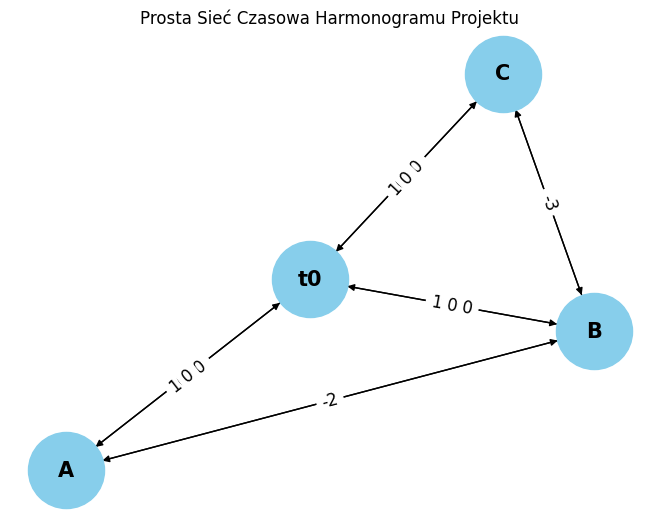

Ograniczenia czasowe są spójne.

Najwcześniejsze czasy rozpoczęcia zadań (względem t0):
Rozpoczęcie zadania A: 995 dni po rozpoczęciu projektu
Rozpoczęcie zadania B: 997 dni po rozpoczęciu projektu
Rozpoczęcie zadania C: 1000 dni po rozpoczęciu projektu


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Tworzymy graf skierowany dla STN
stn = nx.DiGraph()

# Dodajemy wirtualne zdarzenie t0
stn.add_node("t0", time=0)

# Dodajemy zdarzenia reprezentujące rozpoczęcie zadań
stn.add_node("A")
stn.add_node("B")
stn.add_node("C")

# Dodajemy ograniczenia czasowe jako krawędzie z wagami

# Rozpoczęcie B co najmniej 2 dni po rozpoczęciu A: tB - tA >= 2 => tA - tB <= -2
stn.add_edge("B", "A", weight=-2)

# Rozpoczęcie B najpóźniej 5 dni po rozpoczęciu A: tB - tA <= 5
stn.add_edge("A", "B", weight=5)

# Rozpoczęcie C dokładnie 3 dni po rozpoczęciu B: tC - tB = 3
# => tC - tB <= 3 i tC - tB >= 3 => tB - tC <= -3
stn.add_edge("B", "C", weight=3)
stn.add_edge("C", "B", weight=-3)

# Ograniczenia względem t0 (rozpoczęcie nie wcześniej niż w czasie 0)
# Zamiast float('inf'), użyj dużej wartości liczbowej, np. 1000
for task in ["A", "B", "C"]:
    stn.add_edge("t0", task, weight=1000)  # task - t0 <= 1000
    stn.add_edge(task, "t0", weight=0)     # t0 - task <= 0

# Wizualizacja STN (opcjonalnie)
pos = nx.spring_layout(stn)
nx.draw(stn, pos, with_labels=True, node_size=3000, node_color="skyblue",
        font_size=15, font_weight="bold")
edge_labels = nx.get_edge_attributes(stn, 'weight')
nx.draw_networkx_edge_labels(stn, pos, edge_labels=edge_labels, font_size=12)
plt.title("Prosta Sieć Czasowa Harmonogramu Projektu")
plt.show()

# Funkcja sprawdzająca istnienie ujemnych cykli (Bellman-Ford)
def has_negative_cycle(graph, source):
    distance = {node: float('inf') for node in graph.nodes}
    distance[source] = 0
    num_nodes = len(graph.nodes)

    # Relaksacja krawędzi
    for _ in range(num_nodes - 1):
        for u, v, weight in graph.edges.data('weight'):
            if distance[u] != float('inf') and distance[u] + weight < distance[v]:
                distance[v] = distance[u] + weight

    # Sprawdzenie ujemnych cykli
    for u, v, weight in graph.edges.data('weight'):
        if distance[u] != float('inf') and distance[u] + weight < distance[v]:
            return True
    return False

# Sprawdzenie spójności sieci czasowej
if has_negative_cycle(stn, "t0"):
    print("Ograniczenia czasowe są niespójne (wykryto ujemny cykl).")
else:
    print("Ograniczenia czasowe są spójne.")

# Obliczanie najwcześniejszych czasów rozpoczęcia dla każdego zadania
earliest_start_times = {}
for task in stn.nodes:
    if task != "t0":
        earliest_start_times[task] = nx.bellman_ford_path_length(stn, source="t0", target=task, weight="weight")

print("\nNajwcześniejsze czasy rozpoczęcia zadań (względem t0):")
for task, est in earliest_start_times.items():
    print(f"Rozpoczęcie zadania {task}: {est} dni po rozpoczęciu projektu")


Zadanie 1. System Semafora: Rozważmy system semafora z trzema stanami: ZIELONE, ŻÓŁTE, CZERWONE. 1. Zdefiniuj sygnał czasowy NumPy reprezentujący typową sekwencję zmian stanów (ZIELONE →ŻÓŁTE → CZERWONE → ZIELONE...). Sygnał powinien mieć trzy kolumny odpowiadające stanom (True/1.0 jeśli semafor jest w danym stanie, False/0.0 w przeciwnym razie). Pamiętaj o użyciu .astype(float). 2. Zdefiniuj predykaty LinearPredicate: is zielone, is zolte, is czerwone analogicznie do przykładu przełącznika światła. 3. Sformułuj trzy właściwości LTL dla tego systemu, używając metod operatorów czasowych (always, eventually, next, until) na zdefiniowanych predykatach. Przykłady: • ”Zawsze, gdy jest ŻÓŁTE, to następnie będzie CZERWONE.” • ”Kiedyś będzie ZIELONE.” • ”Nigdy nie będzie jednocześnie ZIELONE i CZERWONE.” (Wskazówka: użyj operatora | (lub) i negacji .negation().) 4. Oceń, czy zdefiniowany sygnał czasowy spełnia te trzy właściwości, sprawdzając czy wynik .robustness() jest większy od 0.

In [7]:
import numpy as np
from stlpy.STL import LinearPredicate

# Sygnał czasowy: kolumny to [ZIELONE, ŻÓŁTE, CZERWONE]
signal = np.array([
    [1, 0, 0],  # ZIELONE
    [0, 1, 0],  # ŻÓŁTE
    [0, 0, 1],  # CZERWONE
    [1, 0, 0],  # ZIELONE
    [0, 1, 0],  # ŻÓŁTE
    [0, 0, 1],  # CZERWONE
    [1, 0, 0]   # ZIELONE
]).astype(float)

# Predykaty
is_zielone = LinearPredicate(a=[1, 0, 0], b=0.5, name="is_zielone")
is_zolte   = LinearPredicate(a=[0, 1, 0], b=0.5, name="is_zolte")
is_czerwone= LinearPredicate(a=[0, 0, 1], b=0.5, name="is_czerwone")

# 1. Zawsze, gdy jest ŻÓŁTE, to następnie będzie CZERWONE: G (¬is_zolte ∨ X is_czerwone)
next_czerwone = is_czerwone.eventually(1, 1)
implication_formula = (is_zolte.negation() | next_czerwone).always(0, signal.shape[0] - 2)

# 2. Kiedyś będzie ZIELONE: F is_zielone
eventually_zielone_formula = is_zielone.eventually(0, signal.shape[0] - 1)

# 3. Nigdy nie będzie jednocześnie ZIELONE i CZERWONE: G (¬ZIELONE ∨ ¬CZERWONE)
not_zielone = is_zielone.negation()
not_czerwone = is_czerwone.negation()
never_both_formula = (not_zielone | not_czerwone).always(0, signal.shape[0] - 1)

# Ocena formuł
eval1 = implication_formula.robustness(signal.T, 0) > 0
eval2 = eventually_zielone_formula.robustness(signal.T, 0) > 0
eval3 = never_both_formula.robustness(signal.T, 0) > 0

# Wyniki
print(f"Sygnał semafora:\n{signal}")
print(f"1. Czy zawsze po ŻÓŁTYM jest CZERWONE? {eval1}")
print(f"2. Czy kiedyś jest ZIELONE? {eval2}")
print(f"3. Czy nigdy nie jest jednocześnie ZIELONE i CZERWONE? {eval3}")


Sygnał semafora:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
1. Czy zawsze po ŻÓŁTYM jest CZERWONE? [ True]
2. Czy kiedyś jest ZIELONE? [ True]
3. Czy nigdy nie jest jednocześnie ZIELONE i CZERWONE? [ True]


Zadanie 2. Spójność Zależności Czasowych Zadań: Rozważmy trzy zadania w projekcie: Przygotowanie (P), Realizacja (R) i Testowanie (T). Istnieją następujące ograniczenia czasowe dotyczące ich rozpoczęcia: • Realizacja (R) musi rozpocząć się co najmniej 1 dzień po rozpoczęciu Przygotowania (P). • Realizacja (R) musi rozpocząć się najpóźniej 4 dni po rozpoczęciu Przygotowania (P). • Testowanie (T) musi rozpocząć się co najmniej 2 dni po rozpoczęciu Realizacji (R). Twoim zadaniem jest: 1. Zdefiniuj sieć czasową (STN) dla tych trzech zadań i podanych ograniczeń, używając biblioteki networkx. Pamiętaj o dodaniu wirtualnego zdarzenia początkowego t0. 2. Sprawdź, czy ta sieć czasowa jest spójna za pomocą funkcji do wykrywania ujemnych cykli (możesz użyć funkcji has negative cycle z poprzednich przykładów). 3. Wyświetl wynik informujący, czy podane zależności czasowe między zadaniami są spójne.

In [10]:
import networkx as nx

# Tworzymy skierowany graf reprezentujący sieć czasową
stn = nx.DiGraph()

# Wirtualny punkt początkowy t0
stn.add_node("t0", time=0)

# Zadania: Przygotowanie (P), Realizacja (R), Testowanie (T)
tasks = ["P", "R", "T"]
for task in tasks:
    stn.add_node(task)

# Ograniczenia czasowe:

# R - P >= 1  ⇨  P - R <= -1
stn.add_edge("R", "P", weight=-1)

# R - P <= 4  ⇨  P -> R z wagą 4
stn.add_edge("P", "R", weight=4)

# T - R >= 2  ⇨  R - T <= -2
stn.add_edge("T", "R", weight=-2)

# Ograniczenia względem t0: zadania nie mogą zacząć się przed czasem 0
for task in tasks:
    stn.add_edge("t0", task, weight=1000)  # task - t0 <= 1000
    stn.add_edge(task, "t0", weight=0)     # t0 - task <= 0

def has_negative_cycle(graph, source):
    distance = {node: float('inf') for node in graph.nodes}
    distance[source] = 0
    num_nodes = len(graph.nodes)

    for _ in range(num_nodes - 1):
        for u, v, weight in graph.edges.data('weight'):
            if distance[u] != float('inf') and distance[u] + weight < distance[v]:
                distance[v] = distance[u] + weight

    # Sprawdzenie ujemnych cykli
    for u, v, weight in graph.edges.data('weight'):
        if distance[u] != float('inf') and distance[u] + weight < distance[v]:
            return True
    return False


if has_negative_cycle(stn, "t0"):
    print("Zależności czasowe są niespójne (wykryto ujemny cykl).")
else:
    print("Zależności czasowe są spójne.")



Zależności czasowe są spójne.
